# Mini Project 2 - Classification on tricky data

In [1]:
%pip install torch torchvision torchmetrics pandas numpy matplotlib seaborn scikit-learn tqdm

/Users/kwasus/Desktop/STUDIA/SEM6/SSNE/Neural-Network-Concepts/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split 

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torchmetrics 

from tqdm import tqdm
import random

In [3]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.use_deterministic_algorithms(True)

### Data (Pre)Processing

In [4]:
data = pd.read_csv("./train_data.csv", delimiter=',')
data.head(10)

,SalePrice,YearBuilt,Size(sqf),Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,SubwayStation,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total)
0,141592,2006,814,3,terraced,individual_heating,management_in_trust,111.0,184.0,5min~10min,10min~15min,3.0,0.0,Kyungbuk_uni_hospital,5,6.0,9.0
1,51327,1985,587,8,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3,12.0,4.0
2,48672,1985,587,6,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3,12.0,4.0
3,380530,2006,2056,8,terraced,individual_heating,management_in_trust,249.0,536.0,0~5min,0-5min,5.0,11.0,Sin-nam,5,3.0,7.0
4,78318,1992,644,2,mixed,individual_heating,self_management,142.0,79.0,5min~10min,15min~20min,4.0,8.0,Myung-duk,3,9.0,14.0
5,61946,1993,644,10,mixed,individual_heating,management_in_trust,523.0,536.0,0~5min,15min~20min,8.0,20.0,Myung-duk,4,14.0,17.0
6,84070,1993,644,3,mixed,individual_heating,management_in_trust,523.0,536.0,0~5min,15min~20min,8.0,20.0,Myung-duk,4,14.0,17.0
7,83185,1992,644,13,mixed,individual_heating,self_management,142.0,79.0,5min~10min,15min~20min,4.0,8.0,Myung-duk,3,9.0,14.0
8,168141,1986,1377,4,terraced,central_heating,management_in_trust,713.0,0.0,0~5min,10min~15min,8.0,27.0,Kyungbuk_uni_hospital,4,9.0,6.0
9,153982,1986,914,11,terraced,central_heating,management_in_trust,713.0,0.0,0~5min,10min~15min,8.0,27.0,Kyungbuk_uni_hospital,4,9.0,6.0


In [5]:
data["SalePrice"] = data["SalePrice"].apply(lambda x: 0 if x <= 100000 else 1 if x <=350000 else 2)
data.head(10)

,SalePrice,YearBuilt,Size(sqf),Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,SubwayStation,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total)
0,1,2006,814,3,terraced,individual_heating,management_in_trust,111.0,184.0,5min~10min,10min~15min,3.0,0.0,Kyungbuk_uni_hospital,5,6.0,9.0
1,0,1985,587,8,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3,12.0,4.0
2,0,1985,587,6,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3,12.0,4.0
3,2,2006,2056,8,terraced,individual_heating,management_in_trust,249.0,536.0,0~5min,0-5min,5.0,11.0,Sin-nam,5,3.0,7.0
4,0,1992,644,2,mixed,individual_heating,self_management,142.0,79.0,5min~10min,15min~20min,4.0,8.0,Myung-duk,3,9.0,14.0
5,0,1993,644,10,mixed,individual_heating,management_in_trust,523.0,536.0,0~5min,15min~20min,8.0,20.0,Myung-duk,4,14.0,17.0
6,0,1993,644,3,mixed,individual_heating,management_in_trust,523.0,536.0,0~5min,15min~20min,8.0,20.0,Myung-duk,4,14.0,17.0
7,0,1992,644,13,mixed,individual_heating,self_management,142.0,79.0,5min~10min,15min~20min,4.0,8.0,Myung-duk,3,9.0,14.0
8,1,1986,1377,4,terraced,central_heating,management_in_trust,713.0,0.0,0~5min,10min~15min,8.0,27.0,Kyungbuk_uni_hospital,4,9.0,6.0
9,1,1986,914,11,terraced,central_heating,management_in_trust,713.0,0.0,0~5min,10min~15min,8.0,27.0,Kyungbuk_uni_hospital,4,9.0,6.0


### Check data distribution

Unique labels labels=array([0, 1, 2]), labels_count=array([ 562, 2992,  570])


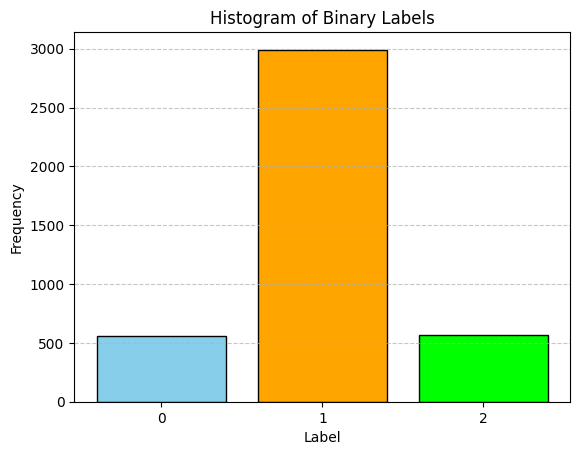

In [6]:
y = data["SalePrice"].to_numpy()
labels, labels_count = np.unique(y, return_counts=True)
print(f"Unique labels {labels=}, {labels_count=}")

plt.bar(x=labels, height=labels_count, color=['skyblue', 'orange', 'lime'], edgecolor='black')
plt.title('Histogram of Binary Labels')
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.xticks(labels)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Prepare Datasets

In [7]:
def get_datasets(data: pd.DataFrame, column_labels: tuple[list, list, str]):
    numerical_columns, categorical_columns, target_column = column_labels
    
    X = data.drop(columns=[target_column])
    y = data[target_column].to_numpy(dtype=int)

    X_num = X[numerical_columns]
    X_cat = pd.get_dummies(X[categorical_columns], dtype=float)
    
    """ 
    2 ways of datasets defining used for experiments / getting best solution
    # 0 - train, val, test dataset splittig with separate numerical and categorical subsets - used in solutions #1 and #2
    # 1 - standarize numerical input, make embeddings from categorical input
    # 2 - leave numerical input as it is, make embeddings from categorical input 
    slightly better without standarization (approx. 0.2 percentage point) 
    """
    
    ### 0
    # train_size = 0.8, val_size = 0.1, test_size = 0.1,
    X_train_num, X_test_num, X_train_cat, X_test_cat, y_train, y_test = train_test_split(X_num, X_cat, y, test_size=0.1, random_state=42, stratify=y)
    X_train_num, X_val_num, X_train_cat, X_val_cat, y_train, y_val = train_test_split(X_train_num, X_train_cat, y_train, test_size=1/9, random_state=42, stratify=y_train)

    print(f"{X_num.shape=}; {X_train_num.shape=}; {X_val_num.shape=}; {X_test_num.shape=}\n")
    print(f"{X_cat.shape=}; {X_train_cat.shape=}; {X_val_cat.shape=}; {X_test_cat.shape=}\n")
    
    ### 1 
    ### standarization only on numerical data, categorical will be transformed into ala embeddings
    # scaler = StandardScaler()
    # X_train_num = scaler.fit_transform(X_train_num)
    # X_val_num = scaler.transform(X_val_num)
    # X_test_num = scaler.transform(X_test_num)
    # # print(X_train_num.shape)

    # datasets = {
    #     "train": TensorDataset(torch.from_numpy(X_train_num).float(), torch.from_numpy(X_train_cat.to_numpy()).float(), y_train),
    #     "val": TensorDataset(torch.from_numpy(X_val_num).float(), torch.from_numpy(X_val_cat.to_numpy()).float(), y_val),
    #     "test": TensorDataset(torch.from_numpy(X_test_num).float(), torch.from_numpy(X_test_cat.to_numpy()).float(), y_test)
    # }

    ### 2
    datasets = {
        "train": TensorDataset(
            torch.tensor(X_train_num.values, dtype=torch.float32), 
            torch.tensor(X_train_cat.values, dtype=torch.float32), 
            torch.tensor(y_train, dtype=torch.int)
        ),
        "val": TensorDataset(
            torch.tensor(X_val_num.values, dtype=torch.float32), 
            torch.tensor(X_val_cat.values, dtype=torch.float32), 
            torch.tensor(y_val, dtype=torch.int)
        ),
        "test": TensorDataset(
            torch.tensor(X_test_num.values, dtype=torch.float32), 
            torch.tensor(X_test_cat.values, dtype=torch.float32), 
            torch.tensor(y_test, dtype=torch.int)
        )
    }

    return datasets


# categorical data will be converted to embeddings - that way there would be less X inputs to NN first linear layer (faster, less resource demanding training) 
target_column = "SalePrice"
categorical_columns = ["HallwayType", "HeatingType", "AptManageType", "TimeToBusStop", "TimeToSubway", "SubwayStation"]
numerical_columns = [col for col in data.columns if col not in categorical_columns + [target_column]]

datasets = get_datasets(data, column_labels=(numerical_columns, categorical_columns, target_column))


X_num.shape=(4124, 10); X_train_num.shape=(3298, 10); X_val_num.shape=(413, 10); X_test_num.shape=(413, 10)

X_cat.shape=(4124, 23); X_train_cat.shape=(3298, 23); X_val_cat.shape=(413, 23); X_test_cat.shape=(413, 23)



### Prepare Dataloaders

In [8]:
batch_size = 128

data_loaders = {stage: DataLoader(datasets[stage], shuffle=stage=="train", num_workers=0, batch_size=batch_size) for stage in datasets}

In [9]:
for (num_X, cat_X, y) in data_loaders["train"]:
    print(f"{num_X.shape=}")
    print(f"{cat_X.shape=}")
    print(f"{y.shape=}")

    break

num_X.shape=torch.Size([128, 10])
cat_X.shape=torch.Size([128, 23])
y.shape=torch.Size([128])


# Model definition + training, evaluation, testing

In [10]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
device

device(type='mps')

In [11]:
class Classifier(nn.Module):
    def __init__(self, num_features_size, cat_features_size, num_classes):
        super(Classifier, self).__init__()
        self.num_features_size = num_features_size
        self.cat_features_size = cat_features_size
        self.num_classes = num_classes

        self.embed_layer = nn.Linear(self.cat_features_size, self.cat_features_size)
        self.embed_act = nn.LeakyReLU()
        self.features_extractor = nn.Sequential(
            nn.Linear(self.num_features_size + self.cat_features_size, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU()
        )
        self.dropout = nn.Dropout(p=0.1)
        self.linear = nn.Linear(64, num_classes)

    def forward(self, numeric_features, cat_features):
        embeddings = self.embed_layer(cat_features)
        embeddings = self.embed_act(embeddings)
        features = self.features_extractor(torch.cat([numeric_features, embeddings], dim=1))
        features = self.dropout(features)
        return self.linear(features)    # logits

### Train / Eval phase

In [12]:
def train(model: nn.Module, loaders: dict[DataLoader], criterion: nn.Module,
          optimizer: torch.optim.Optimizer, lr_scheduler: torch.optim.lr_scheduler, num_epochs: int):

    accumulated_loss = []
    accumulated_acc = []

    metric_loss = torchmetrics.aggregation.MeanMetric().to(device)
    metric_acc = torchmetrics.classification.Accuracy(task="multiclass", num_classes=len(labels)).to(device)

    for epoch in range(1, num_epochs+1):

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            for X_num_batch, X_cat_batch, target in tqdm(loaders[phase]):

                X_num_batch, X_cat_batch, target = X_num_batch.to(device), X_cat_batch.to(device), target.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    logits = model(X_num_batch, X_cat_batch)
                    # dim=1, as columns (dim=1) are 'squeezed' to one max value
                    _, preds = torch.max(logits, dim=1)   # torch.max() --> [values, indices] - pred is index of max value as in softmax highest value will have highest prob as well
                    loss = criterion(logits, target)    # CrossEntropyLoss calculates loss from logits, it has Softmax implemented inside

                    metric_loss(loss)
                    metric_acc(preds, target)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

            acc = metric_acc.compute()
            mean_loss = metric_loss.compute()
            current_lr = lr_scheduler.get_last_lr()[0]

            print(f"(Epoch {epoch}/[{phase}]) Loss:\t{mean_loss:.3f}   Accuracy: {acc:.3f}   lr: {current_lr}")
        
            if phase == "val":
                accumulated_loss.append(float(mean_loss.cpu()))
                accumulated_acc.append(float(acc.cpu()))

            metric_loss.reset()
            metric_acc.reset()

        lr_scheduler.step()

    return accumulated_loss, accumulated_acc

In [13]:
def plot_comparison(acc, loss, title):
    sns.set_theme(style="whitegrid")
    
    fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=False)

    epochs = range(1, len(acc) + 1)
    plt.plot(epochs, acc, label='Accuracy', linewidth=2, marker='o', markersize=4)
    plt.plot(epochs, loss, label='Loss', linewidth=2, marker='o', markersize=4)

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Metrics", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.7)

    fig.subplots_adjust(right=0.72)

    leg = ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
        title="Experiment legend",
        borderaxespad=0.0
    )
    leg.get_frame().set_alpha(1.0)

    plt.show()

In [14]:
for (num_X, cat_X, y) in data_loaders["train"]:
    num_features_size = num_X.shape[1]
    cat_features_size = cat_X.shape[1]
    break

y = data["SalePrice"].to_numpy()
labels, labels_count = np.unique(y, return_counts=True)
print(f"Unique labels {labels=}, {labels_count=}")

class_weights = labels_count.sum() / (len(labels_count) * labels_count)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

Unique labels labels=array([0, 1, 2]), labels_count=array([ 562, 2992,  570])


In [15]:
num_epochs = 50
classifier = Classifier(num_features_size, cat_features_size, len(labels)).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(params=classifier.parameters(), lr=1e-3, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-4)

loss, acc = train(classifier, loaders=data_loaders, criterion=criterion, optimizer=optimizer, lr_scheduler=lr_scheduler, num_epochs=num_epochs)

100%|██████████| 26/26 [00:00<00:00, 41.65it/s]


(Epoch 1/[train]) Loss:	0.674   Accuracy: 0.430   lr: 0.001


100%|██████████| 4/4 [00:00<00:00, 60.66it/s]


(Epoch 1/[val]) Loss:	0.817   Accuracy: 0.291   lr: 0.001


100%|██████████| 26/26 [00:00<00:00, 133.82it/s]


...

(Epoch 49/[val]) Loss:	0.294   Accuracy: 0.782   lr: 0.00010354838440848502


100%|██████████| 26/26 [00:00<00:00, 89.71it/s]


(Epoch 50/[train]) Loss:	0.276   Accuracy: 0.811   lr: 0.0001008879722072778


100%|██████████| 4/4 [00:00<00:00, 135.69it/s]

(Epoch 50/[val]) Loss:	0.294   Accuracy: 0.780   lr: 0.0001008879722072778


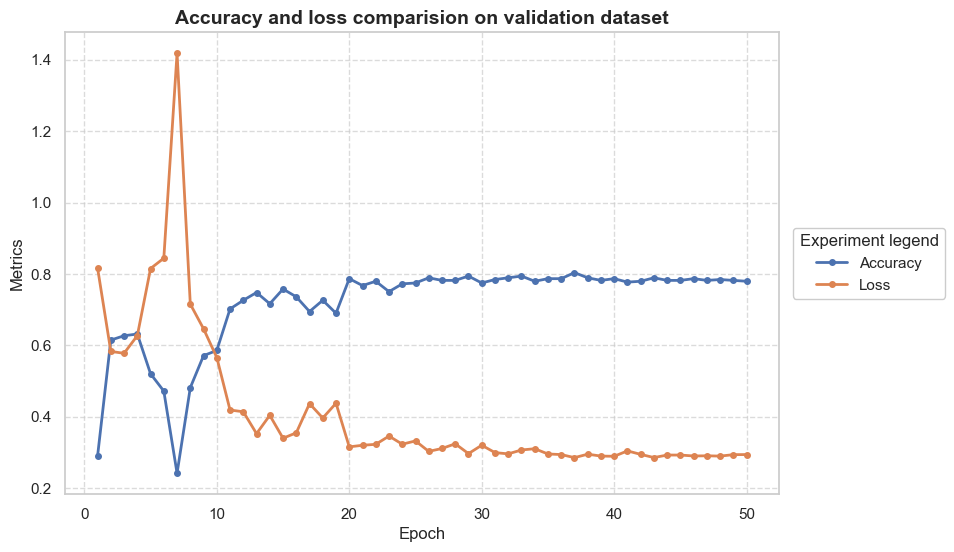

In [16]:
plot_comparison(acc, loss, "Accuracy and loss comparision on validation dataset")

### Test phase

In [17]:
acc_per_class = {0:[0, 0], 1:[0, 0], 2:[0, 0]} # in lists -> [good_preds_numb, class_occurence_numb]
preds_l = []
targets_l = []

classifier.eval()

with torch.inference_mode():    # similar as torch.no_grad()
    for X_num_batch, X_cat_batch, target in tqdm(data_loaders['test']):
        X_num_batch, X_cat_batch, target = X_num_batch.to(device), X_cat_batch.to(device), target.to(device)
        logits = classifier(X_num_batch, X_cat_batch)
        _, preds = torch.max(logits, dim=1)
        
        preds_l.append(preds.cpu())
        targets_l.append(target.cpu())

        for y, pred in zip(target, preds):
            if y == pred:
                acc_per_class[int(y)][0] += 1
            acc_per_class[int(y)][1] += 1


all_preds = torch.cat(preds_l, dim=0)
all_targets = torch.cat(targets_l, dim=0)


print("Accuracy per class - [0, 1, 2]:")
print(f"{[acc_per_class[item][0] / acc_per_class[item][1] * 100 for item in acc_per_class]}\n")


#########################################################################################


def calc_accuracy(pred_targets, targets):
    accuracies = []
    for i in range(3):
        class_correct=(pred_targets == targets.values)[targets == i].sum()
        accuracies.append(class_correct/(targets == i).sum())
    return(np.mean(accuracies))


predictions_student = pd.Series(all_preds.tolist())
labels = pd.Series(all_targets.tolist())

print(f"Final multiclass test accuracy: {calc_accuracy(predictions_student, labels)}")

100%|██████████| 4/4 [00:00<00:00, 11.40it/s]

Accuracy per class - [0, 1, 2]:
[98.21428571428571, 71.66666666666667, 94.73684210526315]

Final multiclass test accuracy: 0.8820593149540518


### test_data.csv - generating answers for evaluations

In [18]:
real_test_data = pd.read_csv("./test_data.csv", delimiter=',')

X_test_num_real = real_test_data[numerical_columns]
X_test_cat_real = pd.get_dummies(real_test_data[categorical_columns], dtype=float)

X_cat_train_columns = pd.get_dummies(data[categorical_columns], dtype=float).columns

# analogicznie do zbioru treningowego
X_test_cat_real = X_test_cat_real.reindex(columns=X_cat_train_columns, fill_value=0)


real_test_dataset = TensorDataset(
    torch.tensor(X_test_num_real.values, dtype=torch.float32), 
    torch.tensor(X_test_cat_real.values, dtype=torch.float32)
)
real_test_loader = DataLoader(real_test_dataset, shuffle=False, num_workers=0, batch_size=batch_size)

Predykcja i zapis

In [19]:
real_preds_l = []
classifier.eval()

with torch.inference_mode():
    for X_num_batch, X_cat_batch in tqdm(real_test_loader):
        X_num_batch, X_cat_batch = X_num_batch.to(device), X_cat_batch.to(device)
        logits = classifier(X_num_batch, X_cat_batch)
        _, preds = torch.max(logits, dim=1)
        real_preds_l.append(preds.cpu())


all_real_preds = torch.cat(real_preds_l, dim=0)
pd.DataFrame(all_real_preds.tolist()).to_csv("pred.csv", index=False, header=False) 

print(f"Generated pred.csv with {len(all_real_preds)} predictions.")

100%|██████████| 14/14 [00:00<00:00, 207.07it/s]

Generated pred.csv with 1767 predictions.
